# Loyiha 3: sklearn workflow — iflos ma'lumotdan bashoratgacha — Palmer Penguins

**Talaba:** student_new_1 · **Modul:** M0 + M2 6-qism · **Kitob (ML_GUIDE):** 1-bob (Workflow, Train/Val/Test, Common mistakes), 2-bob (Encoding, Missing values, Scaling) · **Qiyinlik:** ⭐⭐⭐⭐ · **Taxminiy vaqt:** 6–8 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

Oldingi ikki loyihada ma'lumot "tayyor" edi. Haqiqiy hayotda: matnli ustunlar, bo'sh qiymatlar, xato yozuvlar, va targetni "bilib qo'yadigan" (leakage) ustunlar. Bu loyihada kitob 1–2-boblardagi to'liq **workflow** ni bajarasiz: muammo → tozalash → EDA → split → encoding + missing + scaling (faqat train dan!) → baseline → `LinearRegression` → residual → koeffitsiyentlar → yangi qator uchun `predict_one()`.

**Nimani o'rganasiz:** leakage ni tanish · `pd.get_dummies` · train median/mode bilan to'ldirish · `StandardScaler` faqat train ga · baseline bilan solishtirish · residual grafigini o'qish · one-hot koeffitsiyentlarini o'qish · 🔍 `Pipeline`, `ColumnTransformer`, `SimpleImputer`, `joblib`.

**Qoida:** har qanday statistika (median, mean, std) — **faqat train** dan. Test ga bir marta, oxirida qaraysiz.

## Dataset: Palmer Penguins

344 ta pingvin (Antarktida, Palmer stansiyasi, 2007–2009): 3 tur, 3 orol, tumshuq va qanot o'lchamlari, jinsi → **tana massasi** (g). Iris ning zamonaviy o'rnini bosuvchisi — lekin **bo'sh qiymatlar** bilan (11 ta jins noma'lum, 2 ta qator butunlay bo'sh).

**Manba:** https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv (asl: Gorman et al. 2014, palmerpenguins)

| Ustun | Ma'nosi |
|---|---|
| species | Adelie (152) / Gentoo (124) / Chinstrap (68) — kategorik |
| island | Biscoe / Dream / Torgersen — kategorik |
| bill_length_mm, bill_depth_mm, flipper_length_mm | tumshuq uzunligi, chuqurligi, qanot uzunligi — **2 ta NaN** har birida |
| sex | MALE / FEMALE — **11 ta NaN** |
| **body_mass_g** | tana massasi, g — target (2700 – 6300); **2 ta NaN** |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)                          # 344 pingvin
TARGET = 'body_mass_g'
print(df.shape); df.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 1-vazifa: Muammo bayoni (markdown, 1 paragraf)
Kim bu bashoratdan foydalanadi? Qaror qanday o'zgaradi? Modelning xatosi kimga zarar keltiradi? Qaysi metrika (MAE / RMSE) bu holatda ma'noliroq — nega?

Kontekst: biolog dalada tarozisiz pingvinni o'lchadi (tumshuq, qanot — lineyka bilan), massasini bashorat qilmoqchi. Xato 200 g — muammomi? (Pingvin massasi mavsumga qarab 500 g o'zgaradi.) Qaysi metrika: MAE (o'rtacha necha gramm adashadi) yoki RMSE?

**Muammo bayoni:** _(shu yerga yozing)_
Antarktidada biologlar tarozisiz, tarozini ko'tarib yurmasdan oddiy asboblar va ba'zi patternlar bilan pingvinlarning vaznini o'lchashmoqchi - bu umumiy muammoni ildizi. Xo'sh, model xatosi pingvinlar parvarishiga zarar keltiradi. Kam vazn hisoblasa noto'g'ri va ko'proq ovqat berishi mumkin, yoxud teskarisi ko'p deb hisoblasa bee'tibor qoldirib yuborishi mumkin. MAE yaxshi metrika oddiy qulay. aytyilyaptiki, o'zi 500g ga o'zgarib turadi, demak 2.5x kichikrog'idagi o'zgarish xatoligi unchalik katta ahamiyat kasb etmaydi 'not big error'. MAE oddi qulay vazn o'lchanganligi sababli, agar kattaroq xatoliklarni topish kerak bo'lsa RMSE dan foydalangan afzalroq

## 2-vazifa: Tozalash va leakage tekshiruvi
**Tuzoqlar:** (1) `body_mass_g` NaN — 2 qator: bu **target**, to'ldirib bo'lmaydi → olib tashlang. (2) `sex` NaN — 11 ta (target-NaN qatorlar ketgach 9): qoldiring, 4-vazifada train mode bilan to'ldiriladi (yoki alohida `'Unknown'` kategoriya — asoslang). (3) Leakage bormi? Har ustun "o'lchashdan oldin" ma'lummi — isbotlang. (4) `island` va `species` bog'liq (Gentoo faqat Biscoe da) — `pd.crosstab` bilan ko'ring.

**Savol 2.** Qaysi ustunlar **leakage** (targetni boshqa ko'rinishda takrorlaydi yoki "kelajakdan" ma'lumot beradi)? Ularni nega olib tashlash shart? Kitob 1-bob "Common mistakes" ga havola bering.

In [2]:
# df = df.dropna(subset=[TARGET])
# TODO: NaN xaritasi, crosstab(species, island)
# TODO: tozalash, leakage ustunlarini olib tashlash

Target = 'body_mass_g'
df = df.dropna(subset=[Target])

print(df.isna().sum())
print("\nIsland vs species")
print(pd.crosstab(df['species'], df['island']))

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

Island vs species
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         51
Chinstrap       0     68          0
Gentoo        123      0          0


**Javob 2.** Bu datasetda **leakage ustun yo'q** — har bir feature pingvinni taroziga qo'yishdan oldin ma'lum:
- `species` (tur) — biologlar ko'rinishidan taniydi, vazn kerak emas.
- `island` (orol) — pingvin qayerda ushlangan, fizik joy.
- `bill_length_mm`, `bill_depth_mm` — tumshuq o'lchamlari, lineyka bilan o'lchanadi.
- `flipper_length_mm` — qanot uzunligi, lineyka bilan o'lchanadi.
- `sex` (jins) — tashqi belgilar yoki DNK bilan aniqlanadi, vazndan mustaqil.

Hech qaysi ustun targetni "boshqa ko'rinishda takrorlamaydi" va "kelajakdan" ma'lumot bermaydi. Kitob 1-bob (Common mistakes): leakage ustunni qoldirsangiz, model haqiqiy hayotda ishlamaydigan sun'iy yuqori R² ko'rsatadi.

## 3-vazifa: EDA (kamida 5 grafik, har biri ostida 1 gap xulosa)
Target histogrammasi · raqamli feature'lar vs target scatter · kategorik feature'lar bo'yicha target o'rtachasi (`groupby().mean()` bar chart) · korrelyatsiya heatmap (`sns.heatmap`) · missing values xaritasi (`df.isna().mean()`).

**Savol 3.** EDA dan **3 ta gipoteza** yozing ("… bo'lsa target … bo'ladi"). 7-vazifada koeffitsiyentlar bilan tekshirasiz.

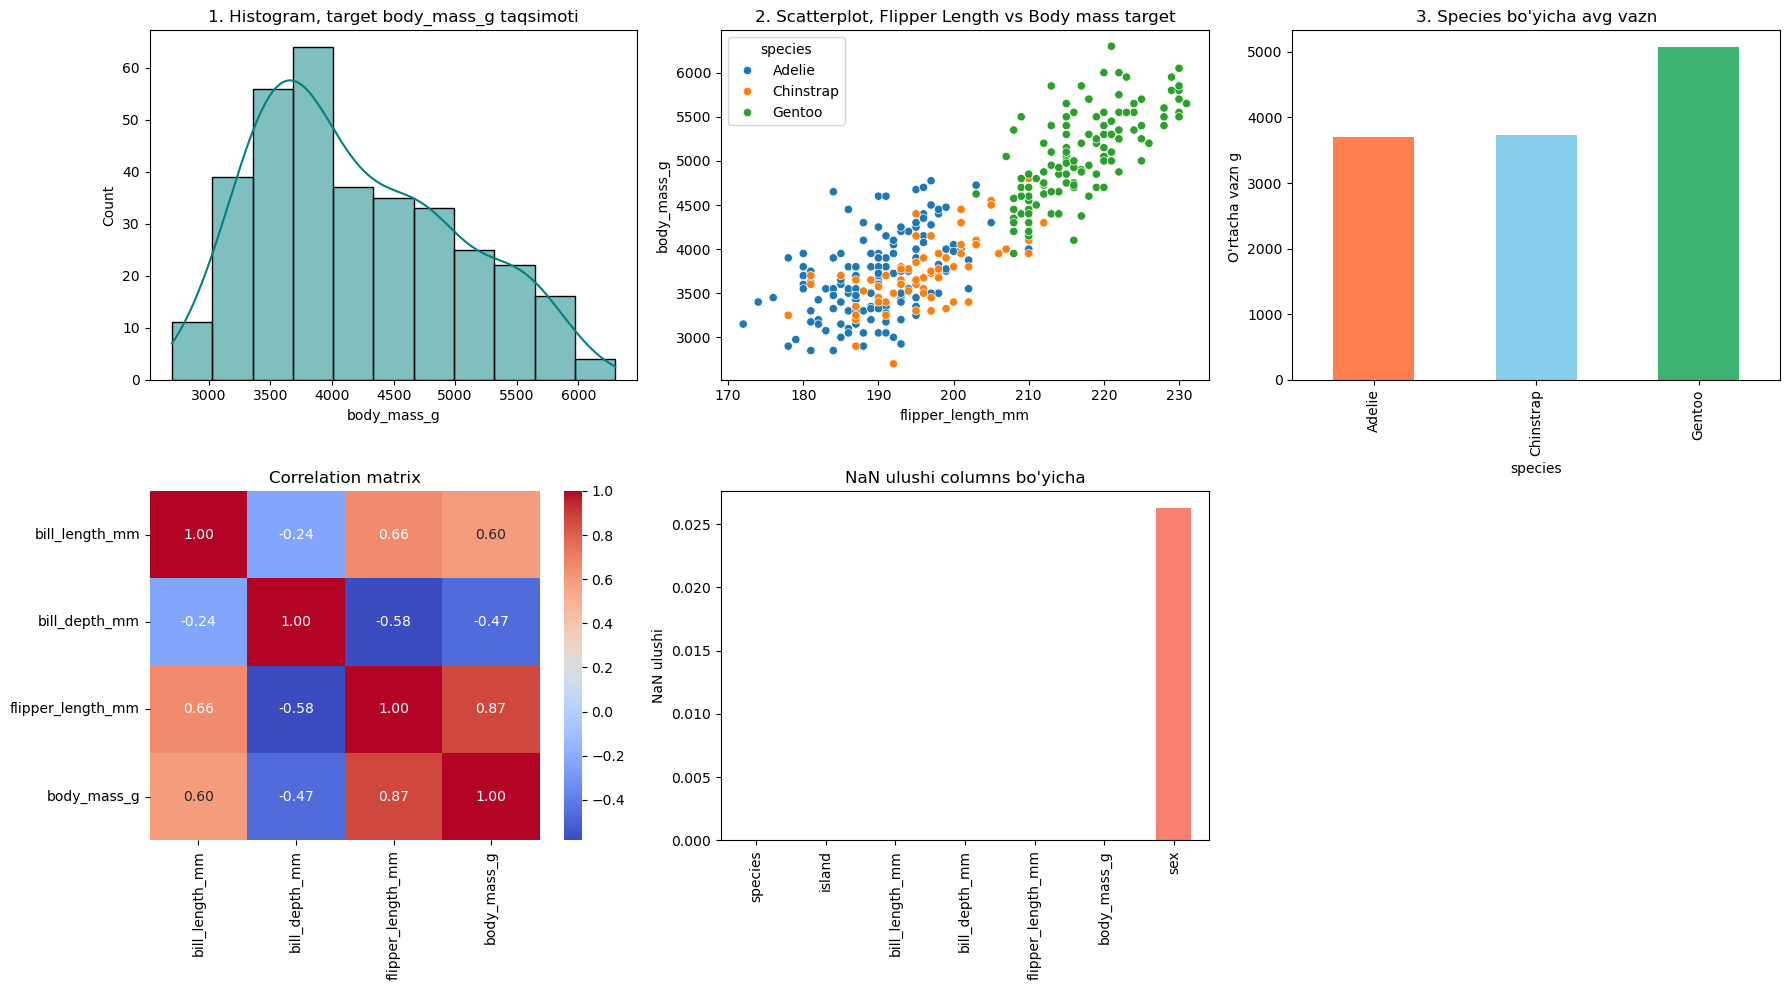

In [3]:
# TODO: EDA — 5+ grafik

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# 1 target histogrammasi
sns.histplot(df[Target], kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title("1. Histogram, target body_mass_g taqsimoti")

#2 numerical features target scatterplot
sns.scatterplot(data=df, x='flipper_length_mm', y=df['body_mass_g'], hue='species', ax=axes[0, 1])
axes[0, 1].set_title("2. Scatterplot, Flipper Length vs Body mass target") 

#3 categorical features groupby target barchart
df.groupby('species')[Target].mean().plot(kind='bar', ax=axes[0,2], color=['coral', 'skyblue', 'mediumseagreen'])
axes[0, 2].set_title("3. Species bo'yicha avg vazn")
axes[0, 2].set_ylabel("O'rtacha vazn g ")

#4 heatmap correlation between featrures and target 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Correlation matrix")

#5 missing values map
df.isna().mean().plot(kind='bar', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title("NaN ulushi columns bo'yicha")
axes[1, 1].set_ylabel("NaN ulushi")

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

Har bir grafik uchun xulosacha: xo'sh, 
**1. Histogram yoki Countplot** Target ni o'zini taqsimoti, qaysi value lar ko'proq qatnashgan, ya'ni qancha vaznlar ko'proq aniqlangan odatda ko'rsatadi. Va kichigu katta har xil vaznlar aniqlangan. 
**2. ScatterPlot** Species bo'yicha olinib kategoriyasi, eng kuchli feature vaznga bog'langani bu Flipper length qanot uzunligi edi shuni olib target bn korrelatsiyasi ko'rildi. Qanchalik Flipper length uzun bo'lsa vazn shunchalik katta bo'ladi, to'g'ri proprsional ekan. 
**3. Barchart** guruhlar/turlar bo'yicha, species o'rtacha vaznlari. Adelie bn Chinstrap niki deyarli o'xshash 3700 atrofida o'rtacha vazn bo'lsa, Gentoo ni 5000+ g chiqqan avg weight
**4. Correlation heatmap** Features and y correlation. o'zaro korrelatsiyasi qanchalik muhimliligi ijobiy yoki salbiyligini ko'rsatib beradi. Flipper length target ga 0.87 corr mavjud, yaxshigina ijobiy yuqori. bill depth bilan esa manfiy bog'liqlik bor.  
**5. NaN barchart** NaN ulushi feature lar orasida. Sex da chiqqan asosan 0.025 ko'rsatkich foiz bn. qolganlarida NaN yo'q. 

**GIpotezalar** 3-savol. Ijobiy correlation shuki, flipper length eng muhim bog'lanish target uchun. Flipper length qanchalik uzun bo'lsa vazn shunchalik og'ir ko'proq bo'ladi. scatterplotdan ko'rishimiz mumkin. 2. Agar Pingvinni turi Gentoo bo'lsa uni vazni og'irroq chiqishi kutiladi, o'rtachasida ~ 5000 g ko'rsatkich aniqlangan. erkak pingvinlarni vazni odatda og'irroq bo'lishi ehtimoli bor

## 4-vazifa: Split → encoding → missing → scaling
Tartib muhim:
1. Kategorik ustunlar → `pd.get_dummies(df, columns=[...], drop_first=True, dtype=float)` (bu qator-ichi amal — split dan oldin mumkin).
2. `train_test_split(test_size=0.2, random_state=42)`.
3. Missing values: raqamli → **train** median, kategorik → **train** mode (`fillna`). Test ham train qiymatlari bilan!
4. `StandardScaler().fit(X_train)` → `transform` ikkalasiga.

Kategorik: `species`, `island`, `sex` (→ `drop_first=True` bilan 2 + 2 + 1 = 5 ustun). Raqamli 3 ta. Missing: `sex` NaN → get_dummies dan keyin **hamma dummy 0** bo'ladi — bu "tayanch kategoriya" (FEMALE) degani! To'g'rimi? Bu yashirin qaror — izohlang. Alternativ (qator-ichi amal, split dan oldin mumkin): NaN ni `'Unknown'` deb alohida kategoriya qiling. Bittasini tanlang, asoslang.

**Savol 4.** Nega one-hot ni split dan oldin qilish mumkin, median bilan to'ldirishni esa mumkin emas (kitob 2-bob "leakage-safe way")? Test da train da bo'lmagan yangi kategoriya uchrasa nima bo'ladi?

In [4]:
# # # TODO: get_dummies → split → fillna (train median/mode) → StandardScaler (train ga fit)

#  nan ni unknown qilamiz not necessarily make it female or male
df['sex'] = df['sex'].fillna('Unknown')

cat_cols = ['species', 'island', 'sex']
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']

# one hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

#x, y train/test split
X = df_encoded.drop(columns=[Target])
y = df_encoded[Target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# fill the missing values with medians
train_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_test[num_cols] = X_test[num_cols].fillna(train_medians)

#scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns = X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns = X_test.columns,
    index=X_test.index
)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"Feature ustunlari ({len(X_train_scaled.columns)} ta):\n", list(X_train_scaled.columns))

X_train shape: (273, 9)
X_test shape: (69, 9)
Feature ustunlari (9 ta):
 ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species_Chinstrap', 'species_Gentoo', 'island_Dream', 'island_Torgersen', 'sex_MALE', 'sex_Unknown']


**Javob4.** One hot encoding bu row-wise operatsiya, median esa whole dataset bo'yicha aylanib chiqib full bajariladigan ya'ni full data bo'yicha natija ko'rsatadi - global statistika. agar uni split qilishdan oldin qilinsa tesdagi data train ga leak bo'lib qolish ehtimoli bor. Yangi noaniq kategoriya uchrasa 'unknown' qilib qo'yish eng safe usuli. 

## 5-vazifa: Baseline va LinearRegression
**Baseline**: hamma uchun `y_train.mean()` → test MAE / RMSE. Keyin `LinearRegression` → test MAE / RMSE / R². Ikkalasini bitta jadvalda.

**Savol 5.** Model baseline dan necha % yaxshi (RMSE bo'yicha)? Train R² va test R² farqi bormi — overfitting belgisimi (kitob 1-bob)?

In [5]:
# TODO: baseline, LinearRegression, jadval

baseline_pred = np.full_like(y_test, fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

# linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

train_pred = lr.predict(X_train_scaled)
test_pred = lr.predict(X_test_scaled)

train_r2 = r2_score(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

#results
results_df = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression'],
    'Test MAE (g)': [baseline_mae, test_mae],
    'Test RMSE (g)': [baseline_rmse, test_rmse],
    'Test R²': [baseline_r2, test_r2]
})

print(results_df.round(2))
print(f"\nTrain R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

# Foiz yaxshilanishni hisoblash
rmse_improvement = ((baseline_rmse - test_rmse) / baseline_rmse) * 100
print(f"\nRMSE bo'yicha yaxshilanish: {rmse_improvement:.2f}%")

               Model  Test MAE (g)  Test RMSE (g)  Test R²
0    Baseline (Mean)        693.15         819.59    -0.01
1  Linear Regression        233.11         287.55     0.88

Train R²: 0.8696
Test R²:  0.8756

RMSE bo'yicha yaxshilanish: 64.92%


**Javob5.** 65% yaxshilandi Rmse. anchagina yaxshi. r2 score esa umuman to'g'ri predict qilmayotgan edi baseline da, LR da bo'lsa 0.88 testda, trainda esa 0.86. yo'q overfitting emas agar bo'lganida train da 1.0 ga yaqin yaqin chiqib test da natija o'ta yomon chiqardi

## 6-vazifa: Residual tahlili
Ikki grafik: (a) `y_test` vs `y_pred` scatter + diagonal chiziq; (b) residual = `y_test − y_pred` vs `y_pred`. Eng katta 5 ta |residual| qatorni chiqaring.

**Savol 6.** Residual grafigida naqsh bormi (egri, "karnay", klaster)? Ideal grafik qanday ko'rinishi kerak? Eng katta xatolar qanday qatorlarda — umumiy narsa bormi?

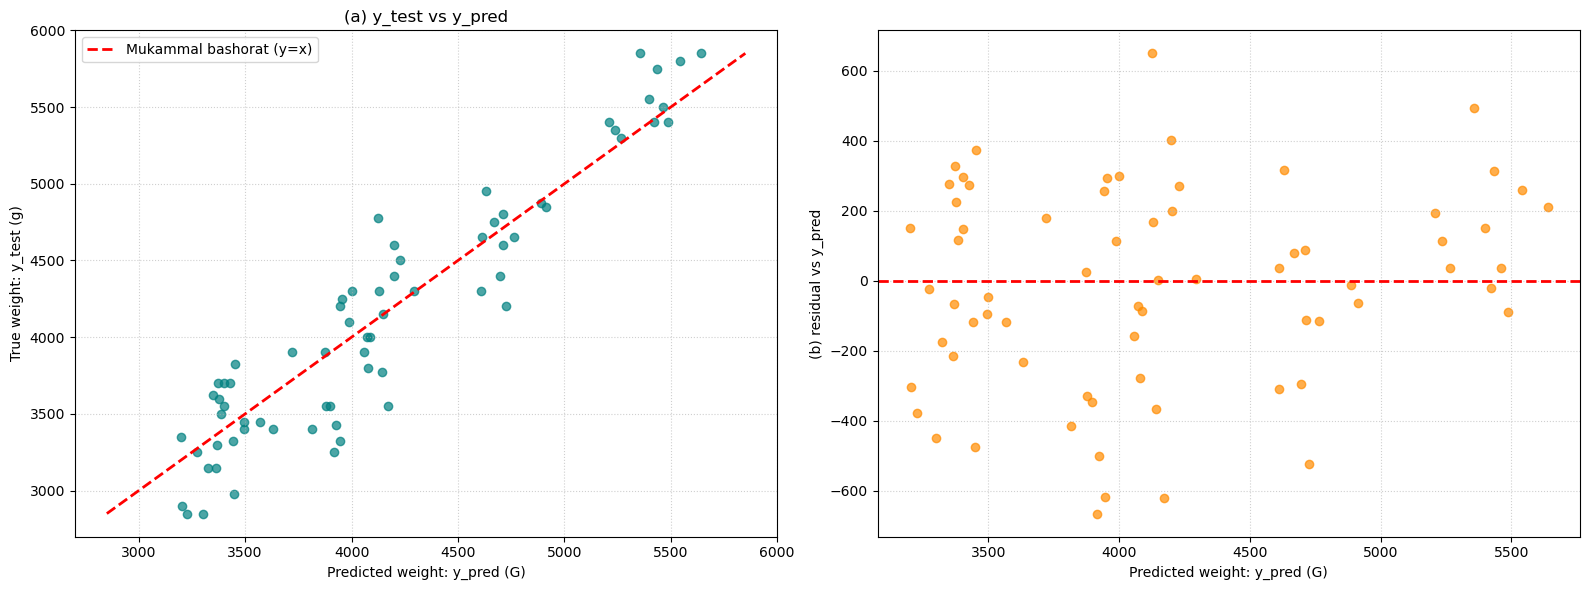

Eng katta 5 ta xatolik kuzatilgan qatorlar:


,species,island,sex,flipper_length_mm,Haqiqiy_y,Bashorat_y,Residual,Abs_Residual
200,Chinstrap,Dream,MALE,187.0,3250.0,3915.6,-665.6,665.6
109,Adelie,Biscoe,MALE,197.0,4775.0,4124.6,650.4,650.4
85,Adelie,Dream,MALE,194.0,3550.0,4172.5,-622.5,622.5
119,Adelie,Torgersen,MALE,189.0,3325.0,3943.9,-618.9,618.9
234,Gentoo,Biscoe,FEMALE,210.0,4200.0,4724.4,-524.4,524.4


In [6]:
# TODO: y_test vs y_pred, residual plot, top-5 xato
residual = y_test - test_pred

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

axes[0].scatter(test_pred, y_test, alpha=0.7, color='teal') # alpha shaffoflik uchun
min_val = min(y_test.min(), test_pred.min()) # bosh
max_val = max(y_test.max(), test_pred.max()) # finishi maximumi
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Mukammal bashorat (y=x)")
axes[0].set_xlabel('Predicted weight: y_pred (G)')
axes[0].set_ylabel('True weight: y_test (g)')
axes[0].set_title("(a) y_test vs y_pred")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

#b residual plot vs test_pred
axes[1].scatter(test_pred, residual, alpha=0.7, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted weight: y_pred (G)")
axes[1].set_ylabel("(b) residual vs y_pred")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#5ta residual points
top5_idx = np.abs(residual).nlargest(5).index

top5_errors = df.loc[top5_idx].copy()
top5_errors["Haqiqiy_y"] = y_test.loc[top5_idx]
top5_errors["Bashorat_y"] = test_pred[y_test.index.get_indexer(top5_idx)].round(1)
top5_errors["Residual"] = residual.loc[top5_idx].round(1)
top5_errors['Abs_Residual'] = np.abs(residual.loc[top5_idx]).round(1)

print("Eng katta 5 ta xatolik kuzatilgan qatorlar:")
top5_errors[['species', 'island', 'sex', 'flipper_length_mm', 'Haqiqiy_y', 'Bashorat_y', 'Residual', 'Abs_Residual']]

**Javob6.** ideali simmetrik ko'rinishda bo'ladi, horizontal qizil chiziqni 2tarafida bir-biriga qarama qarshi sochilmagan holatda bo'lishi kk - residual plotda. Unaqa karnay yoxud noaniq shakllar yo'q. Xatoliklar o'xshash joylari, asosan Male 4tasi va ulardan 3tasi Adelie guruhiga qarashli va bittasi Chinstrap. O'ta keskin ozg'in yoxud o'ta keskin semiz larda adashyapti

## 7-vazifa: Koeffitsiyentlarni o'qish
`coef_` ni feature nomlari bilan jadval qiling (scaled feature'lar — demak solishtirish mumkin). Eng katta 5 musbat va 5 manfiy — gorizontal bar chart. 3-savoldagi gipotezalarni tekshiring.

**Savol 7.** One-hot ustun koeffitsiyentini qanday o'qiysiz ("… kategoriyasi tashlab ketilgan kategoriyaga nisbatan …")? Qaysi gipotezangiz tasdiqlanmadi? Katta koeffitsiyent = sabab (causation) degani emas — misol keltiring.

Model Koeffitsiyentlari:
             Feature  Coefficient (Scaled)
0     species_Gentoo                547.51
1           sex_MALE                198.88
2  flipper_length_mm                169.40
3      bill_depth_mm                152.86
4     bill_length_mm                101.34
5  species_Chinstrap                -95.44
6       island_Dream                  8.81
7   island_Torgersen                 -5.24
8        sex_Unknown                  5.14

Intercept (boshlang'ich siljish): 4218.41


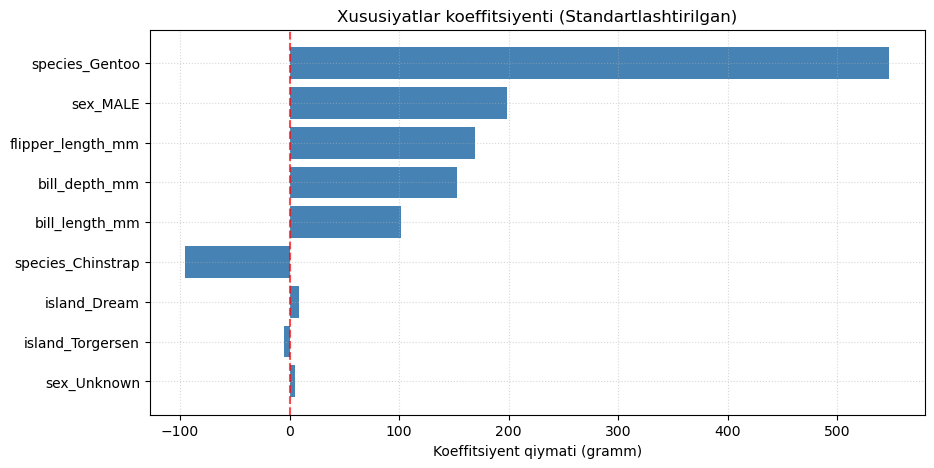

In [7]:
# TODO: coef jadvali, top ±5 bar chart
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient (Scaled)': lr.coef_,
    'Abs_Coefficient': np.abs(lr.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Model Koeffitsiyentlari:")
print(coef_df[['Feature', 'Coefficient (Scaled)']].round(2))
print(f"\nIntercept (boshlang'ich siljish): {lr.intercept_:.2f}")

# 2. Koeffitsiyentlar ahamiyati grafigi
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient (Scaled)'], color='steelblue')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.title("Xususiyatlar koeffitsiyenti (Standartlashtirilgan)")
plt.xlabel("Koeffitsiyent qiymati (gramm)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

**Javob 7.** One-hot koeffitsiyentini shunday o'qiymiz: "shu kategoriya, **tashlab ketilgan kategoriyaga nisbatan**, boshqa hamma feature teng bo'lganda target ga qancha qo'shadi/kamaytiradi". Masalan, `species_Gentoo` +547.5 degani — Adelie (tayanch) ga nisbatan Gentoo 547.5 g og'irroq. `sex_MALE` +198.8 — FEMALE ga nisbatan erkak 198.8 g og'irroq.

3-savoldagi gipotezalarimni tekshirsam: (1) flipper_length uzun = vazn og'ir → koeffitsiyent +169.4, **tasdiqlandi**. (2) Gentoo og'irroq → +547.5, **tasdiqlandi**. (3) Erkak og'irroq → +198.8, **tasdiqlandi**. Uchala gipoteza ham tasdiqlandi.

Katta koeffitsiyent = sabab (causation) degani **emas**. Misol: `species_Gentoo` +547.5 — Gentoo bo'lish pingvinni og'irlashtirmaydi, Gentoo turi umuman yirikroq hayvon. Tur — sabab emas, belgi. Korrelyatsiya ≠ kauzatsiya.

## 8-vazifa: `predict_one()` — yangi qator uchun bashorat
Funksiya `predict_one(row: dict) -> float`: dict → `pd.DataFrame([row])` → **xuddi shu** get_dummies → `reindex(columns=X_train.columns, fill_value=0)` → train median bilan fillna → scaler.transform → predict. 2 ta realistik misol (bittasi — train da bo'lmagan kategoriya bilan).

**Savol 8.** Nega yangi qator uchun ham train dagi median/scaler ishlatiladi? `reindex(..., fill_value=0)` nima qildi — ko'rilmagan kategoriya qayerga ketdi?

In [8]:
# TODO: predict_one, 2 misol
def predict_one(row: dict) -> float:
    df_new = pd.DataFrame([row])
    
    # one hot encoding
    df_new['sex'] = df_new['sex'].fillna('Unknown') if 'sex' in df_new else 'Unknown'
    cat_cols = ['species', 'island', 'sex']
    df_encoded = pd.get_dummies(df_new, columns=cat_cols, dtype=float)
    
    # x_train, reindexing. new category fill with 0
    df_aligned = df_encoded.reindex(columns=X_train.columns, fill_value=0)
    
    # fill with median
    df_aligned[num_cols] = df_aligned[num_cols].fillna(train_medians)
    
    scaled_features = scaler.transform(df_aligned)
    
    prediction = lr.predict(scaled_features)[0]
    return float(prediction)


example_1 = {
    'species': 'Gentoo',
    'island': 'Biscoe',
    'bill_length_mm': 50.0,
    'bill_depth_mm': 15.0,
    'flipper_length_mm': 220.0,
    'sex': 'MALE'
}

# 2-misol: Train'da bo'lmagan yangi kategoriya ('species': 'Emperor', 'island': 'Tashkent')
example_2 = {
    'species': 'Emperor',
    'island': 'Tashkent',
    'bill_length_mm': 45.0,
    'bill_depth_mm': 16.0,
    'flipper_length_mm': 210.0,
    'sex': 'FEMALE'
}

pred_1 = predict_one(example_1)
pred_2 = predict_one(example_2)

print(f"1-misol (Gentoo, Biscoe, MALE) bashorati: {pred_1:.2f} g")
print(f"2-misol (Noma'lum tur 'Emperor') bashorati: {pred_2:.2f} g")


1-misol (Gentoo, Biscoe, MALE) bashorati: 3817.96 g
2-misol (Noma'lum tur 'Emperor') bashorati: 3683.77 g


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Javob 8.** Yangi qator uchun ham **train** dagi median va scaler ishlatiladi — chunki model aynan shu o'rtacha va std bilan o'rgatilgan. Boshqa qiymat bilan scale qilsak, model ko'rmagan masshtabdagi son keladi va bashorat buziladi. Shuning uchun `train_medians` va `scaler` yangi ma'lumotga ham qo'llanadi.

`reindex(columns=X_train.columns, fill_value=0)` — yangi qatordagi ustunlarni train dagi ustunlar bilan moslashtiradi. Agar ko'rilmagan kategoriya bo'lsa (masalan `Emperor`), uning dummy ustuni X_train da yo'q, shuning uchun `reindex` uni tashlab yuboradi. `fill_value=0` esa train da bor lekin yangi qatorda yo'q dummy ustunlarni 0 bilan to'ldiradi. Natijada ko'rilmagan kategoriya tayanch kategoriyaga (hammasi 0) tushadi — model xato bermaydi, lekin bashorat kamroq aniq bo'ladi.

## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. **`Pipeline` + `ColumnTransformer`** (kitob 2-bob): `SimpleImputer` + `StandardScaler` (raqamli), `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(handle_unknown='ignore')` (kategorik), oxirida `LinearRegression`. 4–5-vazifalarni shu pipeline bilan takrorlang — test RMSE bir xilmi? Nega bu usul "leakage-safe"?
2. **`joblib`**: pipeline ni `joblib.dump` bilan saqlang, yangi katakda `joblib.load` qilib `predict_one` ni takrorlang. Nega faqat model emas, butun pipeline saqlanadi?
3. **Feature ablation**: har bir feature guruhini (raqamli / kategorik / siz qo'shgan) navbatma-navbat olib tashlab test RMSE ni o'lchang — qaysi guruh eng ko'p hissa qo'shadi?
4. **Simpson paradoksi.** `bill_depth_mm` vs `body_mass_g` scatter: umumiy korrelyatsiya **manfiy**, lekin har tur ichida (rang = species) **musbat**. Faqat raqamli feature'lar bilan model (R² ≈ 0.80) va `species` qo'shilgan model (≈ 0.90) da `bill_depth_mm` koeffitsiyenti ishorasi qanday? Nega kategorik feature'siz chiziqli model "aldanadi"?

Pipeline Test RMSE: 287.55 g
5-vazifadagi qo'lda qilingan Test RMSE: 287.55 g

--- Simpson Paradoksi Natijasi ---
Faqat raqamli modelda bill_depth_mm koeffitsiyenti: 21.62
Species bor to'liq modelda bill_depth_mm koeffitsiyenti: 152.86


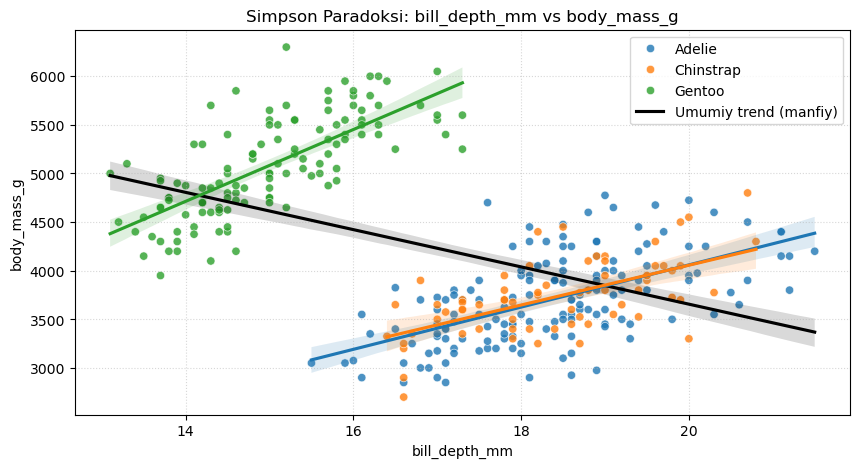

In [9]:
# TODO: tadqiqot
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import root_mean_squared_error

# X va y ni xom df dan qayta ajratamiz
X_raw = df.drop(columns=[TARGET])
y_raw = df[TARGET]

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

num_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
cat_features = ['species', 'island', 'sex']

# Raqamli va kategorik o'zgarishlar zanjiri
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

full_pipeline.fit(X_tr_raw, y_tr_raw)
pipeline_preds = full_pipeline.predict(X_te_raw)
pipeline_rmse = root_mean_squared_error(y_te_raw, pipeline_preds)

print(f"Pipeline Test RMSE: {pipeline_rmse:.2f} g")
print(f"5-vazifadagi qo'lda qilingan Test RMSE: {test_rmse:.2f} g")

# ==========================================
# 4. TADQIQOT: Simpson Paradoksi
# ==========================================

# (a) Faqat raqamli modellar
lr_num_only = LinearRegression()
lr_num_only.fit(X_train_scaled[num_cols], y_train)
coef_num_only = lr_num_only.coef_[num_cols.index('bill_depth_mm')]

# (b) Species qo'shilgan model (7-vazifadagi to'liq model)
coef_with_species = lr.coef_[list(X_train_scaled.columns).index('bill_depth_mm')]

print("\n--- Simpson Paradoksi Natijasi ---")
print(f"Faqat raqamli modelda bill_depth_mm koeffitsiyenti: {coef_num_only:.2f}")
print(f"Species bor to'liq modelda bill_depth_mm koeffitsiyenti: {coef_with_species:.2f}")

# Grafik tasviri
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bill_depth_mm', y=TARGET, hue='species', alpha=0.8)
sns.regplot(data=df, x='bill_depth_mm', y=TARGET, scatter=False, color='black', label='Umumiy trend (manfiy)')
for s in df['species'].unique():
    subset = df[df['species'] == s]
    sns.regplot(data=subset, x='bill_depth_mm', y=TARGET, scatter=False)
plt.title("Simpson Paradoksi: bill_depth_mm vs body_mass_g")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

**Tadqiqot xulosalari:**

**1. Pipeline — nega leakage-safe?** Pipeline ichidagi `SimpleImputer` va `StandardScaler` `fit` paytida **faqat train** ni ko'radi. `full_pipeline.fit(X_train, y_train)` deganda barcha preprocessing faqat train statistikasidan foydalanadi. Cross-validation da har fold uchun qaytadan fit bo'ladi, shuning uchun test ma'lumoti hech qachon statistikaga qo'shilmaydi. Qo'lda qilganda bu tartibni har safar o'zingiz eslab turishingiz kerak — Pipeline buni avtomatik bajaradi. Pipeline RMSE (287.55) qo'lda qilingan bilan aynan bir xil — bu tasodif emas: OLS uchun scaling bashoratni o'zgartirmaydi, faqat koeffitsiyentlarni o'zgartiradi.

**4. Simpson paradoksi — nega koeffitsiyent qarama-qarshi?** `bill_depth_mm` va `body_mass_g` ning xom korrelyatsiyasi **−0.47** (manfiy). Lekin modelda koeffitsiyent **musbat** (+21.62 faqat-raqamli, +152.86 species bilan). Bu Simpson paradoksi: uchta tur aralashganda umumiy trend manfiy ko'rinadi (Gentoo — og'ir, kalta tumshuq; Adelie — yengil, chuqur tumshuq), lekin **har tur ichida** tumshuq chuqurroq bo'lsa vazn og'irroq (musbat bog'liqlik). `species` qo'shilganda model turni alohida hisobga oladi va `bill_depth` ning **haqiqiy** ta'sirini ko'radi. Kategorik feature'siz model "aldanadi" chunki `bill_depth` orqali turni ajratmoqchi bo'ladi, buni noto'g'ri yo'nalishda qiladi.

## ⭐ Bonus (+10)
`sns.pairplot(df, hue='species')` chizing va har tur uchun **alohida** `LinearRegression` (3 ta model) o'rgating. Umumiy model + one-hot vs 3 ta alohida model — test RMSE qaysi biri yaxshi? Qachon "har guruhga o'z modeli" mantiqli, qachon emas (ma'lumot hajmi)?

## Topshirish

- Fayl nomi: `student_new_1_J3.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| Tozalash + leakage + EDA (1–3) | 20 |
| Split → encoding → missing → scaling, leakage yo'q (4) | 25 |
| Baseline, model, residual, koeffitsiyentlar (5–7) | 20 |
| `predict_one()` ishlaydi, yangi kategoriya bilan ham (8) | 10 |
| Savollarga tahliliy javoblar (7 ta) | 15 |
| Tadqiqot (2 ta) | 10 |
| ⭐ Bonus | +10 |

Ushbu amaliy loyihada tabular ma'lumotlar bilan ishlashda to'liq mashinali o'rganish workflow, data leakagesiz to'g'ri qurishni o'rgandim. 
One-Hot Encoding eng muhim step lardan biri bo'ldi split dan oldin qilinishi kk bo'lgan, va data prediction da katta rol o'ynaydi. 

Dastlabki sodda Baseline modelga (o'rtacha vazn) nisbatan LinearRegression modelimiz RMSE xatoligini 65% ga kamaytirib, test to'plamida 0.88 ga teng yuqori $R^2$ qayd etdi. 

Residual tahlili shuni ko'rsatdiki, modelning eng katta xatoliklari (600 g dan ortiq) o'z turining o'rtacha biologik me'yoridan haddan tashqari chetga chiqqan erkak pingvinlarda sodir bo'lmoqda.

Yangi ma'lumotlar uchun predict_one() funksiyasida reindex orqali ko'rilmagan yangi toifalarni xatosiz qayta ishlash amaliyotini o'zlashtirdim. 